#### 1. Environment

In [1]:
!pip uninstall -y torch torchvision torchaudio transformers accelerate -q
!pip install -q --no-cache-dir \
    torch==2.5.1 \
    torchvision==0.20.1 \
    torchaudio==2.5.1 \
    --index-url https://download.pytorch.org/whl/cu121
!pip install -q \
    transformers==4.46.3 \
    accelerate==1.1.1 \
    datasets \
    pillow \
    pandas \
    scikit-learn \
    tqdm \
    huggingface_hub \
    matplotlib \
    pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 297.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 294.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 354.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 285.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 393.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 277.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 352.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 296.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 344.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 355.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 302.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 343.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports and Version Check

In [ ]:
import json
import random
import time
from contextlib import nullcontext
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from datasets import load_dataset
from huggingface_hub import HfApi, create_repo, hf_hub_download
from PIL import Image, ImageOps
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import CLIPImageProcessor, CLIPModel, get_cosine_schedule_with_warmup

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)
    print("GPU capability:", torch.cuda.get_device_capability(0))

Torch: 2.5.1+cu121
Transformers: 4.46.3
CUDA available: True
GPU: Tesla P100-PCIE-16GB
CUDA runtime: 12.1
GPU capability: (6, 0)


## 3. Configuration

In [ ]:
PROJECT_NAME = "AutoCatalogAI"
DATASET_NAME = "ashraq/fashion-product-images-small"
V1_REPO_ID = "mohsin416/autocatalogai-clip-multitask"
V2_REPO_ID = "mohsin416/autocatalogai-clip-multitask-v2"

TASKS = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "usage",
]

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 32
NUM_WORKERS = 0
USE_AMP = True
MAX_GRAD_NORM = 1.0
WEIGHT_DECAY = 1e-2

STAGE1_EPOCHS = 2
STAGE2_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 2

STAGE1_HEAD_LR = 8e-5
STAGE1_NEW_LAYER_LR = 3e-4
STAGE2_HEAD_LR = 5e-5
STAGE2_NEW_LAYER_LR = 1e-4
STAGE2_BACKBONE_LR = 2e-6

UNFREEZE_LAST_N_VISION_LAYERS_STAGE2 = 1
BALANCED_TASKS = {
    "subCategory",
    "articleType",
    "baseColour",
    "usage",
}
CLASS_WEIGHT_MIN = 0.75
CLASS_WEIGHT_MAX = 2.00

COLOR_IMAGE_SIZE = 128
COLOR_FEATURE_DIM = 37

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROOT_DIR = Path(".")
OUTPUT_DIR = ROOT_DIR / "artifacts" / "models" / "autocatalogai_v2"
EVAL_DIR = ROOT_DIR / "artifacts" / "evaluation" / "v2"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
CACHE_DIR = ROOT_DIR / "artifacts" / "cache"

for directory in [OUTPUT_DIR, EVAL_DIR, PROCESSED_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("V1 source:", V1_REPO_ID)
print("V2 target:", V2_REPO_ID)

Device: cuda
V1 source: mohsin416/autocatalogai-clip-multitask
V2 target: mohsin416/autocatalogai-clip-multitask-v2


## 4. Reproducibility

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True


set_seed(SEED)

## 5. Download the Proven V1 Artifacts

In [6]:
def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


v1_model_path = hf_hub_download(
    repo_id=V1_REPO_ID,
    filename="model.pt",
    repo_type="model",
)

v1_config_path = hf_hub_download(
    repo_id=V1_REPO_ID,
    filename="config.json",
    repo_type="model",
)

v1_label_maps_path = hf_hub_download(
    repo_id=V1_REPO_ID,
    filename="label_maps.json",
    repo_type="model",
)

try:
    v1_metrics_path = hf_hub_download(
        repo_id=V1_REPO_ID,
        filename="metrics.json",
        repo_type="model",
    )
except Exception:
    v1_metrics_path = None

with open(v1_config_path, "r", encoding="utf-8") as file:
    v1_config = json.load(file)

with open(v1_label_maps_path, "r", encoding="utf-8") as file:
    label_maps = json.load(file)

v1_checkpoint = safe_torch_load(v1_model_path, map_location="cpu")

if v1_metrics_path:
    with open(v1_metrics_path, "r", encoding="utf-8") as file:
        v1_metrics = json.load(file)
else:
    v1_metrics = {}

MODEL_NAME = (
    v1_config.get("base_model_name")
    or v1_config.get("model_name")
    or v1_checkpoint.get("model_name")
    or "openai/clip-vit-base-patch32"
)

HIDDEN_DIM = int(v1_config.get("hidden_dim", v1_checkpoint.get("hidden_dim", 512)))
DROPOUT = float(v1_config.get("dropout", v1_checkpoint.get("dropout", 0.2)))

task_num_classes = {
    task: len(label_maps[task]["label2id"])
    for task in TASKS
}

print("Base model:", MODEL_NAME)
print("Hidden dimension:", HIDDEN_DIM)
print("Dropout:", DROPOUT)
print("Task classes:", task_num_classes)

model.pt:   0%|          | 0.00/613M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

label_maps.json: 0.00B [00:00, ?B/s]

metrics.json: 0.00B [00:00, ?B/s]

Base model: openai/clip-vit-base-patch32
Hidden dimension: 512
Dropout: 0.2
Task classes: {'gender': 5, 'masterCategory': 7, 'subCategory': 45, 'articleType': 141, 'baseColour': 46, 'season': 4, 'usage': 8}


## 6. Load and Clean the Full Dataset

In [7]:
raw_dataset = load_dataset(DATASET_NAME, split="train")

missing_columns = [
    task for task in TASKS
    if task not in raw_dataset.column_names
]

if "image" not in raw_dataset.column_names:
    raise ValueError(f"Dataset must contain an image column. Found: {raw_dataset.column_names}")

if missing_columns:
    raise ValueError(f"Missing task columns: {missing_columns}")


def is_valid_row(row):
    if row.get("image") is None:
        return False

    for task in TASKS:
        value = row.get(task)

        if value is None:
            return False

        value = str(value).strip()

        if not value:
            return False

        if value not in label_maps[task]["label2id"]:
            return False

    return True


clean_dataset = raw_dataset.filter(is_valid_row)

print("Raw samples:", len(raw_dataset))
print("Clean samples:", len(clean_dataset))

README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…):   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00002-bb459e5ac5f01e(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Filter:   0%|          | 0/44072 [00:00<?, ? examples/s]

Raw samples: 44072
Clean samples: 44072


## 7. Metadata and 70/15/15 Split

In [8]:
metadata = {
    task: [str(value).strip() for value in clean_dataset[task]]
    for task in TASKS
}

if "id" in clean_dataset.column_names:
    metadata["id"] = clean_dataset["id"]

if "productDisplayName" in clean_dataset.column_names:
    metadata["productDisplayName"] = clean_dataset["productDisplayName"]

df = pd.DataFrame(metadata)
df["dataset_idx"] = np.arange(len(clean_dataset))


def make_safe_stratify_labels(series):
    counts = series.value_counts()
    return series.apply(lambda value: value if counts[value] >= 2 else "__rare__")


all_indices = df.index.to_numpy()
article_stratify = make_safe_stratify_labels(df["articleType"])

try:
    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=0.30,
        random_state=SEED,
        stratify=article_stratify,
    )
except ValueError:
    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=0.30,
        random_state=SEED,
        stratify=None,
    )

temp_df = df.loc[temp_idx]
temp_stratify = make_safe_stratify_labels(temp_df["articleType"])

try:
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_stratify,
    )
except ValueError:
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        random_state=SEED,
        stratify=None,
    )

train_df = df.loc[train_idx].copy()
val_df = df.loc[val_idx].copy()
test_df = df.loc[test_idx].copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

train_df.to_csv(PROCESSED_DIR / "train_v2.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val_v2.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test_v2.csv", index=False)

print("Train:", len(train_df), round(len(train_df) / len(df), 4))
print("Validation:", len(val_df), round(len(val_df) / len(df), 4))
print("Test:", len(test_df), round(len(test_df) / len(df), 4))

Train: 30850 0.7
Validation: 6611 0.15
Test: 6611 0.15


## 8. Color Features

In [9]:
def extract_color_features(image, image_size=COLOR_IMAGE_SIZE):
    image = image.convert("RGB").resize((image_size, image_size))

    margin = int(image_size * 0.10)
    image = image.crop((margin, margin, image_size - margin, image_size - margin))

    rgb = np.asarray(image, dtype=np.float32) / 255.0
    hsv = np.asarray(image.convert("HSV"), dtype=np.float32) / 255.0

    rgb_flat = rgb.reshape(-1, 3)
    hsv_flat = hsv.reshape(-1, 3)

    saturation = hsv_flat[:, 1]
    value = hsv_flat[:, 2]

    foreground_mask = (saturation > 0.08) | (value < 0.92)

    if foreground_mask.sum() < 256:
        foreground_mask = np.ones(len(hsv_flat), dtype=bool)

    selected_rgb = rgb_flat[foreground_mask]
    selected_hsv = hsv_flat[foreground_mask]

    hue_hist, _ = np.histogram(selected_hsv[:, 0], bins=12, range=(0.0, 1.0))
    saturation_hist, _ = np.histogram(selected_hsv[:, 1], bins=8, range=(0.0, 1.0))
    value_hist, _ = np.histogram(selected_hsv[:, 2], bins=8, range=(0.0, 1.0))

    hue_hist = hue_hist.astype(np.float32)
    saturation_hist = saturation_hist.astype(np.float32)
    value_hist = value_hist.astype(np.float32)

    hue_hist /= max(hue_hist.sum(), 1.0)
    saturation_hist /= max(saturation_hist.sum(), 1.0)
    value_hist /= max(value_hist.sum(), 1.0)

    rgb_mean = selected_rgb.mean(axis=0).astype(np.float32)
    rgb_std = selected_rgb.std(axis=0).astype(np.float32)
    rgb_median = np.median(selected_rgb, axis=0).astype(np.float32)

    features = np.concatenate([
        hue_hist,
        saturation_hist,
        value_hist,
        rgb_mean,
        rgb_std,
        rgb_median,
    ]).astype(np.float32)

    if features.shape[0] != COLOR_FEATURE_DIM:
        raise ValueError(
            f"Expected {COLOR_FEATURE_DIM} color features, got {features.shape[0]}"
        )

    return features

### Precompute and Cache Color Features

In [10]:
color_cache_path = CACHE_DIR / "fashion_color_features_v2.npy"

if color_cache_path.exists():
    color_features = np.load(color_cache_path)

    if color_features.shape != (len(clean_dataset), COLOR_FEATURE_DIM):
        print("Existing color cache has the wrong shape. Rebuilding it.")
        color_cache_path.unlink()
        color_features = None
else:
    color_features = None

if color_features is None:
    color_features = np.zeros(
        (len(clean_dataset), COLOR_FEATURE_DIM),
        dtype=np.float32,
    )

    for index in tqdm(range(len(clean_dataset)), desc="Extracting color features"):
        color_features[index] = extract_color_features(clean_dataset[index]["image"])

    np.save(color_cache_path, color_features)

print("Color feature matrix:", color_features.shape)

Extracting color features:   0%|          | 0/44072 [00:00<?, ?it/s]

Color feature matrix: (44072, 37)


## 9. Dataset and DataLoaders

In [ ]:
processor = CLIPImageProcessor.from_pretrained(MODEL_NAME)

class HFFashionV2Dataset(Dataset):
    def __init__(
        self,
        source_dataset,
        global_indices,
        color_features,
        processor,
        label_maps,
        tasks,
        training=False,
    ):
        self.source_dataset = source_dataset
        self.global_indices = list(map(int, global_indices))
        self.color_features = color_features
        self.processor = processor
        self.label_maps = label_maps
        self.tasks = tasks
        self.training = training

    def __len__(self):
        return len(self.global_indices)

    def __getitem__(self, index):
        global_index = self.global_indices[index]
        item = self.source_dataset[global_index]
        image = item["image"]

        if not isinstance(image, Image.Image):
            image = Image.open(image)

        image = image.convert("RGB")
        if self.training and random.random() < 0.5:
            image = ImageOps.mirror(image)

        pixel_values = self.processor(
            images=image,
            return_tensors="pt",
        )["pixel_values"].squeeze(0)

        labels = {
            task: torch.tensor(
                self.label_maps[task]["label2id"][str(item[task]).strip()],
                dtype=torch.long,
            )
            for task in self.tasks
        }

        return {
            "pixel_values": pixel_values,
            "color_features": torch.tensor(
                self.color_features[global_index],
                dtype=torch.float32,
            ),
            "labels": labels,
            "global_index": global_index,
        }


def multitask_collate_fn(batch):
    return {
        "pixel_values": torch.stack([item["pixel_values"] for item in batch]),
        "color_features": torch.stack([item["color_features"] for item in batch]),
        "labels": {
            task: torch.stack([item["labels"][task] for item in batch])
            for task in TASKS
        },
        "global_indices": [item["global_index"] for item in batch],
    }


train_dataset = HFFashionV2Dataset(
    clean_dataset,
    train_df["dataset_idx"].tolist(),
    color_features,
    processor,
    label_maps,
    TASKS,
    training=True,
)

val_dataset = HFFashionV2Dataset(
    clean_dataset,
    val_df["dataset_idx"].tolist(),
    color_features,
    processor,
    label_maps,
    TASKS,
    training=False,
)

test_dataset = HFFashionV2Dataset(
    clean_dataset,
    test_df["dataset_idx"].tolist(),
    color_features,
    processor,
    label_maps,
    TASKS,
    training=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=multitask_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=multitask_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=multitask_collate_fn,
)

sample_batch = next(iter(train_loader))
print("Pixel values:", sample_batch["pixel_values"].shape)
print("Color features:", sample_batch["color_features"].shape)
print("Labels:", {task: tensor.shape for task, tensor in sample_batch["labels"].items()})

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

Pixel values: torch.Size([32, 3, 224, 224])
Color features: torch.Size([32, 37])
Labels: {'gender': torch.Size([32]), 'masterCategory': torch.Size([32]), 'subCategory': torch.Size([32]), 'articleType': torch.Size([32]), 'baseColour': torch.Size([32]), 'season': torch.Size([32]), 'usage': torch.Size([32])}


## 10. V2 Model Architecture

In [12]:
class ClassificationHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, hidden_dim=512, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, features):
        return self.net(features)


class CLIPMultiTaskClassifierV2(nn.Module):
    def __init__(
        self,
        model_name,
        task_num_classes,
        hidden_dim=512,
        dropout=0.2,
        color_feature_dim=37,
    ):
        super().__init__()

        self.clip = CLIPModel.from_pretrained(model_name)
        embedding_dim = self.clip.config.projection_dim

        self.heads = nn.ModuleDict({
            task: ClassificationHead(
                embedding_dim=embedding_dim,
                num_classes=num_classes,
                hidden_dim=hidden_dim,
                dropout=dropout,
            )
            for task, num_classes in task_num_classes.items()
        })

        self.master_to_sub = nn.Linear(
            task_num_classes["masterCategory"],
            task_num_classes["subCategory"],
            bias=False,
        )

        self.sub_to_article = nn.Linear(
            task_num_classes["subCategory"],
            task_num_classes["articleType"],
            bias=False,
        )

        self.article_to_season = nn.Linear(
            task_num_classes["articleType"],
            task_num_classes["season"],
            bias=False,
        )

        self.article_to_usage = nn.Linear(
            task_num_classes["articleType"],
            task_num_classes["usage"],
            bias=False,
        )

        self.color_branch = nn.Sequential(
            nn.LayerNorm(color_feature_dim),
            nn.Linear(color_feature_dim, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, task_num_classes["baseColour"]),
        )

        self._initialize_residual_modules()

    def _initialize_residual_modules(self):
        nn.init.zeros_(self.master_to_sub.weight)
        nn.init.zeros_(self.sub_to_article.weight)
        nn.init.zeros_(self.article_to_season.weight)
        nn.init.zeros_(self.article_to_usage.weight)

        final_color_layer = self.color_branch[-1]
        nn.init.zeros_(final_color_layer.weight)
        nn.init.zeros_(final_color_layer.bias)

    def forward(self, pixel_values, color_features):
        image_features = self.clip.get_image_features(pixel_values=pixel_values)
        image_features = F.normalize(image_features, dim=-1)

        outputs = {
            task: head(image_features)
            for task, head in self.heads.items()
        }

        master_probs = torch.softmax(outputs["masterCategory"].detach(), dim=1)
        outputs["subCategory"] = (
            outputs["subCategory"]
            + self.master_to_sub(master_probs)
        )

        sub_probs = torch.softmax(outputs["subCategory"].detach(), dim=1)
        outputs["articleType"] = (
            outputs["articleType"]
            + self.sub_to_article(sub_probs)
        )

        article_probs = torch.softmax(outputs["articleType"].detach(), dim=1)
        outputs["season"] = (
            outputs["season"]
            + self.article_to_season(article_probs)
        )
        outputs["usage"] = (
            outputs["usage"]
            + self.article_to_usage(article_probs)
        )

        outputs["baseColour"] = (
            outputs["baseColour"]
            + self.color_branch(color_features)
        )

        return outputs

## 11. Initialize V2 from V1

In [13]:
model = CLIPMultiTaskClassifierV2(
    model_name=MODEL_NAME,
    task_num_classes=task_num_classes,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    color_feature_dim=COLOR_FEATURE_DIM,
).to(DEVICE)

v1_state_dict = v1_checkpoint.get("model_state_dict", v1_checkpoint)
load_result = model.load_state_dict(v1_state_dict, strict=False)

expected_new_prefixes = (
    "master_to_sub",
    "sub_to_article",
    "article_to_season",
    "article_to_usage",
    "color_branch",
)

unexpected_missing = [
    key for key in load_result.missing_keys
    if not key.startswith(expected_new_prefixes)
]

if unexpected_missing:
    raise RuntimeError(f"Unexpected missing V1 weights: {unexpected_missing}")

if load_result.unexpected_keys:
    raise RuntimeError(f"Unexpected V1 checkpoint keys: {load_result.unexpected_keys}")

print("V1 weights loaded successfully.")
print("New V2 parameters:", load_result.missing_keys)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

V1 weights loaded successfully.
New V2 parameters: ['master_to_sub.weight', 'sub_to_article.weight', 'article_to_season.weight', 'article_to_usage.weight', 'color_branch.0.weight', 'color_branch.0.bias', 'color_branch.1.weight', 'color_branch.1.bias', 'color_branch.4.weight', 'color_branch.4.bias']


## 12. Evaluation Utilities

In [14]:
def top_k_accuracy_from_probs(y_true, probabilities, k=3):
    k = min(k, probabilities.shape[1])
    top_k_indices = np.argsort(-probabilities, axis=1)[:, :k]
    return float(np.mean([
        y_true[index] in top_k_indices[index]
        for index in range(len(y_true))
    ]))


@torch.inference_mode()
def collect_predictions(model, loader, device, max_batches=None):
    model.eval()

    y_true = {task: [] for task in TASKS}
    y_pred = {task: [] for task in TASKS}
    y_probs = {task: [] for task in TASKS}
    global_indices = []

    for batch_index, batch in enumerate(tqdm(loader, desc="Evaluating", leave=False)):
        if max_batches is not None and batch_index >= max_batches:
            break

        pixel_values = batch["pixel_values"].to(device)
        batch_color_features = batch["color_features"].to(device)

        outputs = model(pixel_values, batch_color_features)

        for task in TASKS:
            probabilities = torch.softmax(outputs[task], dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            y_true[task].extend(batch["labels"][task].numpy().tolist())
            y_pred[task].extend(predictions.cpu().numpy().tolist())
            y_probs[task].extend(probabilities.cpu().numpy().tolist())

        global_indices.extend(batch["global_indices"])

    for task in TASKS:
        y_true[task] = np.asarray(y_true[task], dtype=np.int64)
        y_pred[task] = np.asarray(y_pred[task], dtype=np.int64)
        y_probs[task] = np.asarray(y_probs[task], dtype=np.float32)

    return y_true, y_pred, y_probs, global_indices


def evaluate_predictions(y_true, y_pred, y_probs):
    task_metrics = {}

    for task in TASKS:
        task_metrics[task] = {
            "accuracy": float(accuracy_score(y_true[task], y_pred[task])),
            "macro_f1": float(f1_score(
                y_true[task],
                y_pred[task],
                average="macro",
                zero_division=0,
            )),
            "weighted_f1": float(f1_score(
                y_true[task],
                y_pred[task],
                average="weighted",
                zero_division=0,
            )),
            "top3_accuracy": top_k_accuracy_from_probs(
                y_true[task],
                y_probs[task],
                k=3,
            ),
        }

    exact_matches = np.ones(len(y_true[TASKS[0]]), dtype=bool)

    for task in TASKS:
        exact_matches &= y_true[task] == y_pred[task]

    overall_metrics = {
        "average_accuracy": float(np.mean([
            task_metrics[task]["accuracy"] for task in TASKS
        ])),
        "average_macro_f1": float(np.mean([
            task_metrics[task]["macro_f1"] for task in TASKS
        ])),
        "average_weighted_f1": float(np.mean([
            task_metrics[task]["weighted_f1"] for task in TASKS
        ])),
        "average_top3_accuracy": float(np.mean([
            task_metrics[task]["top3_accuracy"] for task in TASKS
        ])),
        "exact_match_accuracy": float(exact_matches.mean()),
        "samples": int(len(exact_matches)),
    }

    return {
        "task_metrics": task_metrics,
        "overall_metrics": overall_metrics,
    }


def model_selection_score(metrics):
    overall = metrics["overall_metrics"]
    color_accuracy = metrics["task_metrics"]["baseColour"]["accuracy"]

    return float(
        0.25 * overall["average_accuracy"]
        + 0.35 * overall["average_macro_f1"]
        + 0.20 * overall["exact_match_accuracy"]
        + 0.20 * color_accuracy
    )


def passes_safety_thresholds(metrics):
    task_metrics = metrics["task_metrics"]
    overall = metrics["overall_metrics"]

    return bool(
        overall["average_accuracy"] >= 0.78
        and task_metrics["masterCategory"]["accuracy"] >= 0.93
        and task_metrics["subCategory"]["accuracy"] >= 0.88
        and task_metrics["articleType"]["accuracy"] >= 0.75
        and task_metrics["usage"]["accuracy"] >= 0.75
    )

## 13. Baseline Safety Check

In [15]:
baseline_y_true, baseline_y_pred, baseline_y_probs, _ = collect_predictions(
    model,
    val_loader,
    DEVICE,
)

baseline_metrics = evaluate_predictions(
    baseline_y_true,
    baseline_y_pred,
    baseline_y_probs,
)

baseline_score = model_selection_score(baseline_metrics)

print(json.dumps(baseline_metrics, indent=2))
print("Baseline validation score:", baseline_score)

if not passes_safety_thresholds(baseline_metrics):
    raise RuntimeError(
        "V1 warm-start sanity check failed. Stop here and verify the V1 checkpoint, "
        "label maps, dataset version, and model architecture before training."
    )

best_score = baseline_score
best_epoch_name = "v1_warm_start"
best_metrics = baseline_metrics

baseline_checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "architecture": "CLIPMultiTaskClassifierV2",
    "architecture_version": "2.0",
    "tasks": TASKS,
    "task_num_classes": task_num_classes,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "color_feature_dim": COLOR_FEATURE_DIM,
    "label_maps": label_maps,
    "best_epoch": best_epoch_name,
    "best_validation_score": float(best_score),
    "best_validation_metrics": best_metrics,
    "source_v1_repo": V1_REPO_ID,
}

torch.save(baseline_checkpoint, OUTPUT_DIR / "model.pt")

with open(EVAL_DIR / "baseline_validation_metrics.json", "w", encoding="utf-8") as file:
    json.dump(baseline_metrics, file, indent=2, ensure_ascii=False)

print("Safe V1-equivalent fallback checkpoint saved.")

Evaluating:   0%|          | 0/207 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

{
  "task_metrics": {
    "gender": {
      "accuracy": 0.8833761911964907,
      "macro_f1": 0.7625688564706268,
      "weighted_f1": 0.8945160877909046,
      "top3_accuracy": 0.9966722129783694
    },
    "masterCategory": {
      "accuracy": 0.9942520042353653,
      "macro_f1": 0.8981406061408509,
      "weighted_f1": 0.9940790689514357,
      "top3_accuracy": 0.999394947814249
    },
    "subCategory": {
      "accuracy": 0.9476629859325367,
      "macro_f1": 0.7738755498992085,
      "weighted_f1": 0.9505854959792596,
      "top3_accuracy": 0.9941007411889276
    },
    "articleType": {
      "accuracy": 0.8487369535622448,
      "macro_f1": 0.6776052518280037,
      "weighted_f1": 0.856479018212125,
      "top3_accuracy": 0.9767054908485857
    },
    "baseColour": {
      "accuracy": 0.6133716533050976,
      "macro_f1": 0.35352595804026105,
      "weighted_f1": 0.6449594381841708,
      "top3_accuracy": 0.8637119951595825
    },
    "season": {
      "accuracy": 0.71683557706

## 14. Mild Capped Class Weights

In [16]:
def compute_capped_class_weights(dataframe, task, label_maps):
    label2id = label_maps[task]["label2id"]
    num_classes = len(label2id)

    encoded = dataframe[task].map(label2id).to_numpy(dtype=np.int64)
    counts = np.bincount(encoded, minlength=num_classes).astype(np.float64)

    weights = np.sqrt(
        counts.sum() / (num_classes * np.maximum(counts, 1.0))
    )
    weights /= max(weights.mean(), 1e-8)
    weights = np.clip(weights, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)

    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


criterions = {}
class_weight_summary = {}

for task in TASKS:
    if task in BALANCED_TASKS:
        weights = compute_capped_class_weights(train_df, task, label_maps)
        criterions[task] = nn.CrossEntropyLoss(weight=weights)
        class_weight_summary[task] = {
            "min": float(weights.min().item()),
            "max": float(weights.max().item()),
            "mean": float(weights.mean().item()),
        }
    else:
        criterions[task] = nn.CrossEntropyLoss()
        class_weight_summary[task] = None

print(json.dumps(class_weight_summary, indent=2))

{
  "gender": null,
  "masterCategory": null,
  "subCategory": {
    "min": 0.75,
    "max": 2.0,
    "mean": 1.0664552450180054
  },
  "articleType": {
    "min": 0.75,
    "max": 2.0,
    "mean": 1.087828516960144
  },
  "baseColour": {
    "min": 0.75,
    "max": 2.0,
    "mean": 1.0325320959091187
  },
  "season": null,
  "usage": {
    "min": 0.75,
    "max": 2.0,
    "mean": 1.0029233694076538
  }
}


## 15. Training Utilities

In [17]:
def get_autocast_context(device, use_amp):
    if not use_amp or not str(device).startswith("cuda"):
        return nullcontext()

    try:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=True)


def create_scaler(device, use_amp):
    enabled = use_amp and str(device).startswith("cuda")

    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def compute_loss(outputs, labels, criterions, active_tasks):
    losses = [
        criterions[task](outputs[task], labels[task])
        for task in active_tasks
    ]

    return torch.stack(losses).mean()


def configure_stage(model, stage):
    for parameter in model.parameters():
        parameter.requires_grad = False

    new_modules = [
        model.master_to_sub,
        model.sub_to_article,
        model.article_to_season,
        model.article_to_usage,
        model.color_branch,
    ]

    for module in new_modules:
        for parameter in module.parameters():
            parameter.requires_grad = True

    if stage == 1:
        active_tasks = [
            "gender",
            "subCategory",
            "articleType",
            "baseColour",
            "season",
            "usage",
        ]

        for task in active_tasks:
            for parameter in model.heads[task].parameters():
                parameter.requires_grad = True

        learning_rates = {
            "head": STAGE1_HEAD_LR,
            "new": STAGE1_NEW_LAYER_LR,
            "backbone": None,
        }

    elif stage == 2:
        active_tasks = TASKS.copy()

        for head in model.heads.values():
            for parameter in head.parameters():
                parameter.requires_grad = True

        vision_layers = model.clip.vision_model.encoder.layers

        for layer in vision_layers[-UNFREEZE_LAST_N_VISION_LAYERS_STAGE2:]:
            for parameter in layer.parameters():
                parameter.requires_grad = True

        for parameter in model.clip.visual_projection.parameters():
            parameter.requires_grad = True

        for parameter in model.clip.vision_model.post_layernorm.parameters():
            parameter.requires_grad = True

        learning_rates = {
            "head": STAGE2_HEAD_LR,
            "new": STAGE2_NEW_LAYER_LR,
            "backbone": STAGE2_BACKBONE_LR,
        }

    else:
        raise ValueError(f"Unknown stage: {stage}")

    return active_tasks, learning_rates


def create_optimizer_and_scheduler(model, stage, epochs, steps_per_epoch):
    active_tasks, learning_rates = configure_stage(model, stage)

    new_parameter_ids = {
        id(parameter)
        for module in [
            model.master_to_sub,
            model.sub_to_article,
            model.article_to_season,
            model.article_to_usage,
            model.color_branch,
        ]
        for parameter in module.parameters()
        if parameter.requires_grad
    }

    head_parameters = []
    new_parameters = []
    backbone_parameters = []

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        if id(parameter) in new_parameter_ids:
            new_parameters.append(parameter)
        elif name.startswith("heads"):
            head_parameters.append(parameter)
        else:
            backbone_parameters.append(parameter)

    parameter_groups = []

    if head_parameters:
        parameter_groups.append({
            "params": head_parameters,
            "lr": learning_rates["head"],
        })

    if new_parameters:
        parameter_groups.append({
            "params": new_parameters,
            "lr": learning_rates["new"],
        })

    if backbone_parameters and learning_rates["backbone"] is not None:
        parameter_groups.append({
            "params": backbone_parameters,
            "lr": learning_rates["backbone"],
        })

    optimizer = torch.optim.AdamW(
        parameter_groups,
        weight_decay=WEIGHT_DECAY,
    )

    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, int(0.10 * total_steps))

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    scaler = create_scaler(DEVICE, USE_AMP)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(f"Stage {stage} active tasks:", active_tasks)
    print(f"Stage {stage} trainable parameters:", f"{trainable_parameters:,}")
    print(f"Stage {stage} total optimizer steps:", total_steps)

    return active_tasks, optimizer, scheduler, scaler

In [18]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    scaler,
    criterions,
    active_tasks,
    device,
):
    model.train()

    running_loss = 0.0
    correct_counts = {task: 0 for task in TASKS}
    sample_count = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        batch_color_features = batch["color_features"].to(device)
        labels = {
            task: tensor.to(device)
            for task, tensor in batch["labels"].items()
        }

        optimizer.zero_grad(set_to_none=True)

        with get_autocast_context(device, USE_AMP):
            outputs = model(pixel_values, batch_color_features)
            loss = compute_loss(
                outputs,
                labels,
                criterions,
                active_tasks,
            )

        if USE_AMP and str(device).startswith("cuda"):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

        scheduler.step()

        batch_size = pixel_values.size(0)
        sample_count += batch_size
        running_loss += loss.item() * batch_size

        for task in TASKS:
            predictions = torch.argmax(outputs[task], dim=1)
            correct_counts[task] += int((predictions == labels[task]).sum().item())

        progress_bar.set_postfix({
            "loss": round(loss.item(), 4),
            "color_acc": round(
                correct_counts["baseColour"] / max(sample_count, 1),
                4,
            ),
        })

    average_loss = running_loss / max(sample_count, 1)
    accuracies = {
        task: correct_counts[task] / max(sample_count, 1)
        for task in TASKS
    }

    return average_loss, accuracies

## 16. Conservative Consistency Rules

In [19]:
def build_consistency_rule(dataframe, source_task, target_task):
    rule = {}

    for source_value, group in dataframe.groupby(source_task):
        counts = group[target_task].value_counts()
        target_value = counts.index[0]
        dominance = float(counts.iloc[0] / counts.sum())

        rule[source_value] = {
            "target": target_value,
            "dominance": dominance,
        }

    return rule


consistency_rules = {
    "article_to_master": build_consistency_rule(
        train_df,
        "articleType",
        "masterCategory",
    ),
    "article_to_sub": build_consistency_rule(
        train_df,
        "articleType",
        "subCategory",
    ),
    "article_to_usage": build_consistency_rule(
        train_df,
        "articleType",
        "usage",
    ),
    "article_to_season": build_consistency_rule(
        train_df,
        "articleType",
        "season",
    ),
}

with open(OUTPUT_DIR / "consistency_rules.json", "w", encoding="utf-8") as file:
    json.dump(consistency_rules, file, indent=2, ensure_ascii=False)


def apply_consistency_rules(y_pred, y_probs):
    corrected = {
        task: predictions.copy()
        for task, predictions in y_pred.items()
    }

    article_id2label = label_maps["articleType"]["id2label"]

    for index in range(len(corrected["articleType"])):
        article_id = int(corrected["articleType"][index])
        article_label = article_id2label[str(article_id)]
        article_confidence = float(y_probs["articleType"][index, article_id])

        if article_confidence < 0.65:
            continue

        mappings = [
            ("article_to_master", "masterCategory", 0.95),
            ("article_to_sub", "subCategory", 0.90),
            ("article_to_usage", "usage", 0.92),
            ("article_to_season", "season", 0.92),
        ]

        for rule_name, target_task, minimum_dominance in mappings:
            rule = consistency_rules[rule_name].get(article_label)

            if not rule or rule["dominance"] < minimum_dominance:
                continue

            target_label = rule["target"]
            corrected[target_task][index] = label_maps[target_task]["label2id"][target_label]

    return corrected

## 17. Two-Stage Fine-Tuning

In [20]:
training_history = []
training_start = time.time()


def evaluate_validation_model(model):
    y_true, y_pred, y_probs, _ = collect_predictions(
        model,
        val_loader,
        DEVICE,
    )

    raw_metrics = evaluate_predictions(y_true, y_pred, y_probs)
    corrected_y_pred = apply_consistency_rules(y_pred, y_probs)
    corrected_metrics = evaluate_predictions(y_true, corrected_y_pred, y_probs)

    combined_metrics = {
        "raw": raw_metrics,
        "corrected": corrected_metrics,
    }

    score = model_selection_score(raw_metrics)
    return combined_metrics, score


def save_best_checkpoint(model, epoch_name, score, metrics):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "architecture": "CLIPMultiTaskClassifierV2",
        "architecture_version": "2.0",
        "tasks": TASKS,
        "task_num_classes": task_num_classes,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "color_feature_dim": COLOR_FEATURE_DIM,
        "label_maps": label_maps,
        "best_epoch": epoch_name,
        "best_validation_score": float(score),
        "best_validation_metrics": metrics,
        "source_v1_repo": V1_REPO_ID,
    }

    torch.save(checkpoint, OUTPUT_DIR / "model.pt")


for stage, stage_epochs in [(1, STAGE1_EPOCHS), (2, STAGE2_EPOCHS)]:
    active_tasks, optimizer, scheduler, scaler = create_optimizer_and_scheduler(
        model,
        stage=stage,
        epochs=stage_epochs,
        steps_per_epoch=len(train_loader),
    )

    bad_epochs = 0

    for epoch in range(1, stage_epochs + 1):
        epoch_name = f"stage_{stage}_epoch_{epoch}"
        print(f"\n{epoch_name}")

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterions=criterions,
            active_tasks=active_tasks,
            device=DEVICE,
        )

        validation_metrics, validation_score = evaluate_validation_model(model)
        raw_metrics = validation_metrics["raw"]
        corrected_metrics = validation_metrics["corrected"]
        safety_passed = passes_safety_thresholds(raw_metrics)

        record = {
            "epoch": epoch_name,
            "train_loss": float(train_loss),
            "train_accuracy": {
                task: float(value)
                for task, value in train_acc.items()
            },
            "validation_score": float(validation_score),
            "safety_passed": bool(safety_passed),
            "validation_metrics": validation_metrics,
        }

        training_history.append(record)

        summary = {
            "epoch": epoch_name,
            "train_loss": record["train_loss"],
            "validation_score": record["validation_score"],
            "safety_passed": record["safety_passed"],
            "raw_overall": validation_metrics["raw"]["overall_metrics"],
            "corrected_overall": validation_metrics["corrected"]["overall_metrics"],
            "baseColour_accuracy": corrected_metrics["task_metrics"]["baseColour"]["accuracy"],
        }

        print(json.dumps(summary, indent=2))

        if safety_passed and validation_score > best_score:
            best_score = validation_score
            best_epoch_name = epoch_name
            best_metrics = validation_metrics
            bad_epochs = 0

            save_best_checkpoint(
                model,
                epoch_name,
                validation_score,
                validation_metrics,
            )

            print("Saved improved V2 checkpoint.")
        else:
            bad_epochs += 1
            print(f"Checkpoint rejected. Bad epochs: {bad_epochs}")

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping stage {stage}.")
            break

with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as file:
    json.dump(training_history, file, indent=2, ensure_ascii=False)

training_minutes = round((time.time() - training_start) / 60, 2)

print("Best checkpoint:", best_epoch_name)
print("Best validation score:", best_score)
print("Training minutes:", training_minutes)

Stage 1 active tasks: ['gender', 'subCategory', 'articleType', 'baseColour', 'season', 'usage']
Stage 1 trainable parameters: 1,723,665
Stage 1 total optimizer steps: 1930

stage_1_epoch_1


Training:   0%|          | 0/965 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/207 [00:00<?, ?it/s]

{
  "epoch": "stage_1_epoch_1",
  "train_loss": 0.3643387914554033,
  "validation_score": 0.6792057716290167,
  "safety_passed": true,
  "raw_overall": {
    "average_accuracy": 0.8758562568878709,
    "average_macro_f1": 0.6818324125021072,
    "average_weighted_f1": 0.8725011700708599,
    "average_top3_accuracy": 0.980876029128941,
    "exact_match_accuracy": 0.40659506882468616,
    "samples": 6611
  },
  "corrected_overall": {
    "average_accuracy": 0.8762884370205503,
    "average_macro_f1": 0.6780631517001316,
    "average_weighted_f1": 0.8728462225193089,
    "average_top3_accuracy": 0.980876029128941,
    "exact_match_accuracy": 0.4084102253819392,
    "samples": 6611
  },
  "baseColour_accuracy": 0.7014067463318712
}
Saved improved V2 checkpoint.

stage_1_epoch_2


Training:   0%|          | 0/965 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/207 [00:00<?, ?it/s]

{
  "epoch": "stage_2_epoch_2",
  "train_loss": 0.2790148842740484,
  "validation_score": 0.6842456388069336,
  "safety_passed": true,
  "raw_overall": {
    "average_accuracy": 0.8785141647038487,
    "average_macro_f1": 0.6816274315268281,
    "average_weighted_f1": 0.8745623173399982,
    "average_top3_accuracy": 0.9810056831687447,
    "exact_match_accuracy": 0.4209650582362729,
    "samples": 6611
  },
  "corrected_overall": {
    "average_accuracy": 0.8788599088099921,
    "average_macro_f1": 0.6798503837922079,
    "average_weighted_f1": 0.874862374929344,
    "average_top3_accuracy": 0.9810056831687447,
    "exact_match_accuracy": 0.4220238995613372,
    "samples": 6611
  },
  "baseColour_accuracy": 0.7092724247466344
}
Saved improved V2 checkpoint.

stage_2_epoch_3


Training:   0%|          | 0/965 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/207 [00:00<?, ?it/s]

{
  "epoch": "stage_2_epoch_3",
  "train_loss": 0.26918605472318935,
  "validation_score": 0.6850541292538551,
  "safety_passed": true,
  "raw_overall": {
    "average_accuracy": 0.8790543898696977,
    "average_macro_f1": 0.6810448843443148,
    "average_weighted_f1": 0.875300002033101,
    "average_top3_accuracy": 0.9810489011820127,
    "exact_match_accuracy": 0.4226289517470882,
    "samples": 6611
  },
  "corrected_overall": {
    "average_accuracy": 0.879573006028913,
    "average_macro_f1": 0.6798874617843464,
    "average_weighted_f1": 0.8757899369197171,
    "average_top3_accuracy": 0.9810489011820127,
    "exact_match_accuracy": 0.42444410830434126,
    "samples": 6611
  },
  "baseColour_accuracy": 0.711995159582514
}
Saved improved V2 checkpoint.
Best checkpoint: stage_2_epoch_3
Best validation score: 0.6850541292538551
Training minutes: 15.25


## 18. Load the Best Safe Checkpoint

In [21]:
best_checkpoint = safe_torch_load(
    OUTPUT_DIR / "model.pt",
    map_location=DEVICE,
)

model = CLIPMultiTaskClassifierV2(
    model_name=best_checkpoint["model_name"],
    task_num_classes=best_checkpoint["task_num_classes"],
    hidden_dim=best_checkpoint["hidden_dim"],
    dropout=best_checkpoint["dropout"],
    color_feature_dim=best_checkpoint["color_feature_dim"],
).to(DEVICE)

model.load_state_dict(best_checkpoint["model_state_dict"], strict=True)
model.eval()

print("Loaded checkpoint:", best_checkpoint["best_epoch"])
print("Validation score:", best_checkpoint["best_validation_score"])

Loaded checkpoint: stage_2_epoch_3
Validation score: 0.6850541292538551


## 19. Final Test Evaluation

In [22]:
test_y_true, test_y_pred, test_y_probs, test_global_indices = collect_predictions(
    model,
    test_loader,
    DEVICE,
)

raw_test_metrics = evaluate_predictions(
    test_y_true,
    test_y_pred,
    test_y_probs,
)

corrected_test_y_pred = apply_consistency_rules(
    test_y_pred,
    test_y_probs,
)

corrected_test_metrics = evaluate_predictions(
    test_y_true,
    corrected_test_y_pred,
    test_y_probs,
)

print("Raw test metrics")
print(json.dumps(raw_test_metrics, indent=2))

print("\nConsistency-corrected test metrics")
print(json.dumps(corrected_test_metrics, indent=2))

Evaluating:   0%|          | 0/207 [00:00<?, ?it/s]

Raw test metrics
{
  "task_metrics": {
    "gender": {
      "accuracy": 0.9192255332022387,
      "macro_f1": 0.8120023642434658,
      "weighted_f1": 0.9171197435057891,
      "top3_accuracy": 0.9974285282105582
    },
    "masterCategory": {
      "accuracy": 0.9944032672818031,
      "macro_f1": 0.8464411154349717,
      "weighted_f1": 0.9934568742235771,
      "top3_accuracy": 0.999394947814249
    },
    "subCategory": {
      "accuracy": 0.963545605808501,
      "macro_f1": 0.7593135523586715,
      "weighted_f1": 0.9615599935457707,
      "top3_accuracy": 0.9972772651641204
    },
    "articleType": {
      "accuracy": 0.876418091060354,
      "macro_f1": 0.6636649938278787,
      "weighted_f1": 0.8687058623934012,
      "top3_accuracy": 0.9815459083345939
    },
    "baseColour": {
      "accuracy": 0.697171381031614,
      "macro_f1": 0.3649654467037918,
      "weighted_f1": 0.6854616546763269,
      "top3_accuracy": 0.9069732264407805
    },
    "season": {
      "accuracy":

## 20. Clean Latency Benchmarks

In [23]:
@torch.inference_mode()
def benchmark_single_image_latency(
    model,
    dataset,
    device,
    warmup_runs=20,
    measured_runs=100,
):
    model.eval()
    sample = dataset[0]

    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
    sample_color_features = sample["color_features"].unsqueeze(0).to(device)

    for _ in range(warmup_runs):
        _ = model(pixel_values, sample_color_features)

    if str(device).startswith("cuda"):
        torch.cuda.synchronize()

    times = []

    for _ in range(measured_runs):
        if str(device).startswith("cuda"):
            torch.cuda.synchronize()

        start = time.perf_counter()
        _ = model(pixel_values, sample_color_features)

        if str(device).startswith("cuda"):
            torch.cuda.synchronize()

        times.append((time.perf_counter() - start) * 1000.0)

    return {
        "average_ms": float(np.mean(times)),
        "p50_ms": float(np.percentile(times, 50)),
        "p95_ms": float(np.percentile(times, 95)),
        "runs": int(measured_runs),
    }


@torch.inference_mode()
def benchmark_batch_latency(model, loader, device, max_batches=100):
    model.eval()
    per_image_times = []

    for batch_index, batch in enumerate(tqdm(loader, desc="Batch benchmark", leave=False)):
        if batch_index >= max_batches:
            break

        pixel_values = batch["pixel_values"].to(device)
        batch_color_features = batch["color_features"].to(device)

        if str(device).startswith("cuda"):
            torch.cuda.synchronize()

        start = time.perf_counter()
        _ = model(pixel_values, batch_color_features)

        if str(device).startswith("cuda"):
            torch.cuda.synchronize()

        elapsed_ms = (time.perf_counter() - start) * 1000.0
        per_image_times.append(elapsed_ms / pixel_values.size(0))

    return {
        "average_ms_per_image": float(np.mean(per_image_times)),
        "p50_ms_per_image": float(np.percentile(per_image_times, 50)),
        "p95_ms_per_image": float(np.percentile(per_image_times, 95)),
        "batches": int(len(per_image_times)),
    }


single_image_latency = benchmark_single_image_latency(
    model,
    test_dataset,
    DEVICE,
)

batch_latency = benchmark_batch_latency(
    model,
    test_loader,
    DEVICE,
)

latency_metrics = {
    "device": DEVICE,
    "single_image": single_image_latency,
    "batch": batch_latency,
}

print(json.dumps(latency_metrics, indent=2))

Batch benchmark:   0%|          | 0/207 [00:00<?, ?it/s]

{
  "device": "cuda",
  "single_image": {
    "average_ms": 6.040507929997148,
    "p50_ms": 5.991619500036904,
    "p95_ms": 6.485346800127445,
    "runs": 100
  },
  "batch": {
    "average_ms_per_image": 1.4842246653120128,
    "p50_ms_per_image": 1.4831240312496163,
    "p95_ms_per_image": 1.498824745313243,
    "batches": 100
  }
}


## 21. Save Reports, Confusion Matrices, and Predictions

In [24]:
final_metrics = {
    "raw": raw_test_metrics,
    "corrected": corrected_test_metrics,
    "latency": latency_metrics,
    "best_checkpoint": best_checkpoint["best_epoch"],
    "best_validation_score": best_checkpoint["best_validation_score"],
    "test_samples": len(test_dataset),
}

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(final_metrics, file, indent=2, ensure_ascii=False)

with open(EVAL_DIR / "final_metrics.json", "w", encoding="utf-8") as file:
    json.dump(final_metrics, file, indent=2, ensure_ascii=False)

for variant_name, predictions in {
    "raw": test_y_pred,
    "corrected": corrected_test_y_pred,
}.items():
    for task in TASKS:
        id2label = label_maps[task]["id2label"]
        label_ids = list(range(len(id2label)))
        label_names = [id2label[str(label_id)] for label_id in label_ids]

        report = classification_report(
            test_y_true[task],
            predictions[task],
            labels=label_ids,
            target_names=label_names,
            zero_division=0,
            output_dict=True,
        )

        with open(
            EVAL_DIR / f"{variant_name}_{task}_classification_report.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(report, file, indent=2, ensure_ascii=False)

        matrix = confusion_matrix(
            test_y_true[task],
            predictions[task],
            labels=label_ids,
        )

        pd.DataFrame(
            matrix,
            index=label_names,
            columns=label_names,
        ).to_csv(
            EVAL_DIR / f"{variant_name}_{task}_confusion_matrix.csv",
            encoding="utf-8",
        )

prediction_rows = []

for row_index, global_index in enumerate(test_global_indices):
    row = {
        "global_index": int(global_index),
    }

    raw_exact = True
    corrected_exact = True

    for task in TASKS:
        id2label = label_maps[task]["id2label"]
        true_id = int(test_y_true[task][row_index])
        raw_id = int(test_y_pred[task][row_index])
        corrected_id = int(corrected_test_y_pred[task][row_index])

        row[f"{task}_true"] = id2label[str(true_id)]
        row[f"{task}_raw"] = id2label[str(raw_id)]
        row[f"{task}_corrected"] = id2label[str(corrected_id)]
        row[f"{task}_confidence"] = float(test_y_probs[task][row_index, raw_id])

        raw_exact &= true_id == raw_id
        corrected_exact &= true_id == corrected_id

    row["raw_exact_match"] = bool(raw_exact)
    row["corrected_exact_match"] = bool(corrected_exact)
    prediction_rows.append(row)

pd.DataFrame(prediction_rows).to_csv(
    EVAL_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8",
)

print("Reports and predictions saved successfully.")

Reports and predictions saved successfully.


## 22. Single Product Prediction and Catalog Output

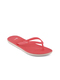

{
  "prediction": {
    "gender": {
      "label": "Women",
      "confidence": 0.8827637434005737,
      "top_3": [
        {
          "label": "Women",
          "confidence": 0.8827637434005737
        },
        {
          "label": "Men",
          "confidence": 0.07194693386554718
        },
        {
          "label": "Unisex",
          "confidence": 0.04517087712883949
        }
      ]
    },
    "masterCategory": {
      "label": "Footwear",
      "confidence": 0.9999488592147827,
      "top_3": [
        {
          "label": "Footwear",
          "confidence": 0.9999488592147827
        },
        {
          "label": "Personal Care",
          "confidence": 4.5643315388588235e-05
        },
        {
          "label": "Apparel",
          "confidence": 2.372275730522233e-06
        }
      ]
    },
    "subCategory": {
      "label": "Flip Flops",
      "confidence": 0.9887700080871582,
      "top_3": [
        {
          "label": "Flip Flops",
          "confidence": 

In [25]:
def normalize_text(value):
    if value is None:
        return ""

    return " ".join(
        str(value).strip().replace("_", " ").replace("-", " ").split()
    )


def generate_catalog_output(predicted_labels):
    gender = normalize_text(predicted_labels.get("gender"))
    color = normalize_text(predicted_labels.get("baseColour"))
    usage = normalize_text(predicted_labels.get("usage"))
    article_type = normalize_text(predicted_labels.get("articleType"))
    master_category = normalize_text(predicted_labels.get("masterCategory"))
    sub_category = normalize_text(predicted_labels.get("subCategory"))
    season = normalize_text(predicted_labels.get("season"))

    title = " ".join([
        value
        for value in [gender, color, usage, article_type]
        if value
    ])

    candidate_tags = [
        f"{gender} {article_type}",
        f"{color} {article_type}",
        f"{usage} {sub_category}",
        f"{season} {master_category}",
        f"{gender} {usage} wear",
        f"{color} {usage} fashion",
        sub_category,
        article_type,
    ]

    tags = []

    for tag in candidate_tags:
        normalized = normalize_text(tag).lower()

        if normalized and normalized not in tags:
            tags.append(normalized)

    return {
        "suggested_title": title,
        "search_tags": tags,
        "json_export": {
            "gender": gender,
            "category": master_category,
            "subcategory": sub_category,
            "article_type": article_type,
            "color": color,
            "season": season,
            "usage": usage,
            "title": title,
            "tags": tags,
        },
    }


@torch.inference_mode()
def predict_single_item(item, model, processor, device, top_k=3):
    model.eval()

    image = item["image"].convert("RGB")
    pixel_values = processor(
        images=image,
        return_tensors="pt",
    )["pixel_values"].to(device)

    item_color_features = torch.tensor(
        extract_color_features(image),
        dtype=torch.float32,
    ).unsqueeze(0).to(device)

    outputs = model(pixel_values, item_color_features)

    prediction = {}
    simple_predictions = {}

    for task in TASKS:
        probabilities = torch.softmax(outputs[task], dim=1).squeeze(0)
        k = min(top_k, probabilities.numel())
        top_probabilities, top_indices = torch.topk(probabilities, k=k)

        top_items = []

        for probability, label_index in zip(top_probabilities, top_indices):
            label = label_maps[task]["id2label"][str(int(label_index.item()))]
            top_items.append({
                "label": label,
                "confidence": float(probability.item()),
            })

        prediction[task] = {
            "label": top_items[0]["label"],
            "confidence": top_items[0]["confidence"],
            "top_3": top_items,
        }
        simple_predictions[task] = top_items[0]["label"]

    return {
        "prediction": prediction,
        "catalog_output": generate_catalog_output(simple_predictions),
    }


sample_item = clean_dataset[int(test_df.iloc[0]["dataset_idx"])]
sample_result = predict_single_item(
    sample_item,
    model,
    processor,
    DEVICE,
    top_k=3,
)

display(sample_item["image"])
print(json.dumps(sample_result, indent=2, ensure_ascii=False))

## 23. Save Configuration and Model Card

In [26]:
config = {
    "project_name": PROJECT_NAME,
    "version": "2.0",
    "dataset_name": DATASET_NAME,
    "source_v1_repo": V1_REPO_ID,
    "base_model_name": MODEL_NAME,
    "architecture": "CLIPMultiTaskClassifierV2",
    "tasks": TASKS,
    "task_num_classes": task_num_classes,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "color_feature_dim": COLOR_FEATURE_DIM,
    "color_image_size": COLOR_IMAGE_SIZE,
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "balanced_tasks": sorted(BALANCED_TASKS),
    "class_weight_min": CLASS_WEIGHT_MIN,
    "class_weight_max": CLASS_WEIGHT_MAX,
    "best_checkpoint": best_checkpoint["best_epoch"],
    "best_validation_score": best_checkpoint["best_validation_score"],
}

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as file:
    json.dump(config, file, indent=2, ensure_ascii=False)

with open(OUTPUT_DIR / "label_maps.json", "w", encoding="utf-8") as file:
    json.dump(label_maps, file, indent=2, ensure_ascii=False)

corrected_overall = corrected_test_metrics["overall_metrics"]
corrected_tasks = corrected_test_metrics["task_metrics"]

model_card = f"""---
library_name: transformers
pipeline_tag: image-classification
tags:
- clip
- fashion
- multi-task-learning
- product-attribute-extraction
- color-histogram
- hierarchical-classification
---

# AutoCatalogAI V2

AutoCatalogAI V2 starts from the proven V1 checkpoint and adds a lightweight color branch and hierarchical residual connections.

## Dataset

`{DATASET_NAME}`

- Train: 70%
- Validation: 15%
- Test: 15%

## Base Model

`{MODEL_NAME}`

## Corrected Test Metrics

- Average accuracy: {corrected_overall['average_accuracy']:.4f}
- Average macro F1: {corrected_overall['average_macro_f1']:.4f}
- Average weighted F1: {corrected_overall['average_weighted_f1']:.4f}
- Average top-3 accuracy: {corrected_overall['average_top3_accuracy']:.4f}
- Exact-match accuracy: {corrected_overall['exact_match_accuracy']:.4f}
- Base-colour accuracy: {corrected_tasks['baseColour']['accuracy']:.4f}

## Loading

This repository contains a custom PyTorch architecture. Use the AutoCatalogAI V2 project code to load `model.pt` together with `config.json`, `label_maps.json`, and `consistency_rules.json`.
"""

with open(OUTPUT_DIR / "README.md", "w", encoding="utf-8") as file:
    file.write(model_card)

print("Final artifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Final artifacts:
- README.md
- config.json
- consistency_rules.json
- history.json
- label_maps.json
- metrics.json
- model.pt


## 24. Upload to Hugging Face Hub

In [ ]:
HF_TOKEN = "HF_TOKEN"

api = HfApi(token=HF_TOKEN)

create_repo(
    repo_id=V2_REPO_ID,
    repo_type="model",
    token=HF_TOKEN,
    private=False,
    exist_ok=True,
)

api.upload_folder(
    folder_path=str(OUTPUT_DIR),
    repo_id=V2_REPO_ID,
    repo_type="model",
    token=HF_TOKEN,
)

print("Uploaded to:", V2_REPO_ID)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to: mohsin416/autocatalogai-clip-multitask-v2
